In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
df = pd.read_csv("Accidental_Drug_Related_Deaths_2012-2024.csv")
df.head()

,Date,Date Type,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,...,Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,ResidenceCityGeo,InjuryCityGeo,DeathCityGeo
0,01/02/2023,Date of death,65.0,Male,White,"No, not Spanish/Hispanic/Latino",BRIDGEPORT,FAIRFIELD,CT,BRIDGEPORT,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"BRIDGEPORT, CT\n(41.179195, -73.189476)","BRIDGEPORT, CT\n(41.179195, -73.189476)","CT\n(41.57350273, -72.738305908)"
1,01/18/2023,Date of death,42.0,Male,White,"No, not Spanish/Hispanic/Latino",WATERBURY,NEW HAVEN,CT,FARMINGTON,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"WATERBURY, CT\n(41.5542609, -73.0430692)","FARMINGTON, CT\n(41.726536, -72.8250564)","CT\n(41.57350273, -72.738305908)"
2,01/26/2022,Date of death,34.0,Male,White,NaN,BROOKFIELD,FAIRFIELD,CT,BROOKFIELD,...,Y,NaN,NaN,Y,NaN,Y,NaN,"BROOKFIELD, CT\n(41.46736000000004, -73.398259...","BROOKFIELD, CT\n(41.46736000000004, -73.398259...","CT\n(41.57350273000003, -72.73830590799997)"
3,02/04/2023,Date of death,34.0,Male,White,NaN,NaN,NaN,NaN,NEW HAVEN,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"CT\n(41.57350273, -72.738305908)","NEW HAVEN, CT\n(41.3082517, -72.9241605)","CT\n(41.57350273, -72.738305908)"
4,02/18/2022,Date of death,43.0,Male,White,NaN,NORWICH,NEW LONDON,CT,NORWICH,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"NORWICH, CT\n(41.526760000000024, -72.07567999...","NORWICH, CT\n(41.526760000000024, -72.07567999...","CT\n(41.57350273000003, -72.73830590799997)"


In [4]:
df.info()
df.shape
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 12963 entries, 0 to 12962
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           12963 non-null  str    
 1   Date Type                      12963 non-null  str    
 2   Age                            12961 non-null  float64
 3   Sex                            12954 non-null  str    
 4   Race                           12897 non-null  str    
 5   Ethnicity                      3435 non-null   str    
 6   Residence City                 12320 non-null  str    
 7   Residence County               11655 non-null  str    
 8   Residence State                10927 non-null  str    
 9   Injury City                    12706 non-null  str    
 10  Injury County                  9527 non-null   str    
 11  Injury State                   9849 non-null   str    
 12  Injury Place                   12573 non-null  str    
 1

Morphine (Not Heroin)            12901
Hydromorphone                    12883
Meth/Amphetamine                 12836
Opiate NOS                       12835
Hydrocodone                      12790
Oxymorphone                      12788
Tramad                           12653
Other Opioid                     12650
Amphet                           12468
Gabapentin                       12408
Heroin death certificate (DC)    12223
Other                            12086
Fentanyl Analogue                11942
Oxycodone                        11893
Methadone                        11772
Location if Other                11769
Other Significant Conditions     11614
Xylazine                         11543
Heroin/Morph/Codeine             10700
Benzodiazepine                   10052
Ethanol                           9630
Ethnicity                         9528
Heroin                            9324
Cocaine                           7799
Death State                       6090
Death County             

In [5]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [6]:
df.drop(['CaseNumber','Unnamed:_0'], axis=1, inplace=True, errors='ignore')
df.drop_duplicates(inplace=True)

In [7]:
mean_data=df['Age'] = df['Age'].fillna(df['Age'].mean())
print(mean_data)

0        65.0
1        42.0
2        34.0
3        34.0
4        43.0
         ... 
12958    48.0
12959    53.0
12960    31.0
12961    66.0
12962    53.0
Name: Age, Length: 12963, dtype: float64


In [8]:
mode_data=df['Sex'] = df['Sex'].fillna(df['Sex'].mode()[0])
print(mode_data)

0          Male
1          Male
2          Male
3          Male
4          Male
          ...  
12958      Male
12959      Male
12960      Male
12961      Male
12962    Female
Name: Sex, Length: 12963, dtype: str


In [9]:
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

In [10]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [11]:
df['Sex'] = df['Sex'].str.upper().str.strip()
df['Race'] = df['Race'].fillna('Unknown').str.upper().str.strip()

In [12]:
drug_cols = ['Fentanyl', 'Heroin', 'Cocaine']

for col in drug_cols:
    if col in df.columns:
        df[col] = df[col].map({'Y':1, 'N':0})

df['Fentanyl'] = df['Fentanyl'].fillna(0).astype(int)

In [13]:
df.drop(['Death_State','Death_County','Death_City','Injury_County'], axis=1, inplace=True, errors='ignore')

In [14]:
df['Any_Opioid'] = df['Any_Opioid'].fillna('Unknown')
df['Residence_State'] = df['Residence_State'].fillna('Unknown')
df['Injury_State'] = df['Injury_State'].fillna('Unknown')

cols = ['Residence_County','Description_of_Injury','Residence_City']
for col in cols:
    df[col] = df[col].fillna('Unknown')

df['Manner_of_Death'] = df['Manner_of_Death'].fillna('Unknown')

In [15]:
df.drop(['Location'], axis=1, inplace=True)

df['Injury_City'] = df['Injury_City'].fillna('Unknown')
df['Injury_Place'] = df['Injury_Place'].fillna('Unknown')

df['ResidenceCityGeo'] = df['ResidenceCityGeo'].fillna('Unknown')
df['InjuryCityGeo'] = df['InjuryCityGeo'].fillna('Unknown')
df['DeathCityGeo'] = df['DeathCityGeo'].fillna('Unknown')

In [16]:
bins = [0,18,30,45,60,100]
labels = ['Teen','Young','Adult','Mid','Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [17]:

df = df[df['Sex'] != 'UNKNOWN']
df['Age_Group'] = pd.Categorical(df['Age_Group'], 
                                categories=['Teen','Young','Adult','Mid','Senior'], 
                                ordered=True)
df['Manner_of_Death'] = df['Manner_of_Death'].str.upper().str.strip()
df['Any_Opioid'] = df['Any_Opioid'].replace({'Y':'Yes','N':'No'})

In [18]:
df['Fentanyl_Label'] = df['Fentanyl'].replace({1:'Yes', 0:'No'})

In [19]:
df[['Fentanyl', 'Fentanyl_Label']].head()

,Fentanyl,Fentanyl_Label
0,1,Yes
1,1,Yes
2,1,Yes
3,1,Yes
4,1,Yes


In [20]:
df['Manner_of_Death'] = df['Manner_of_Death'].replace({
    'ACCIDENT': 'ACCIDENTAL'
})

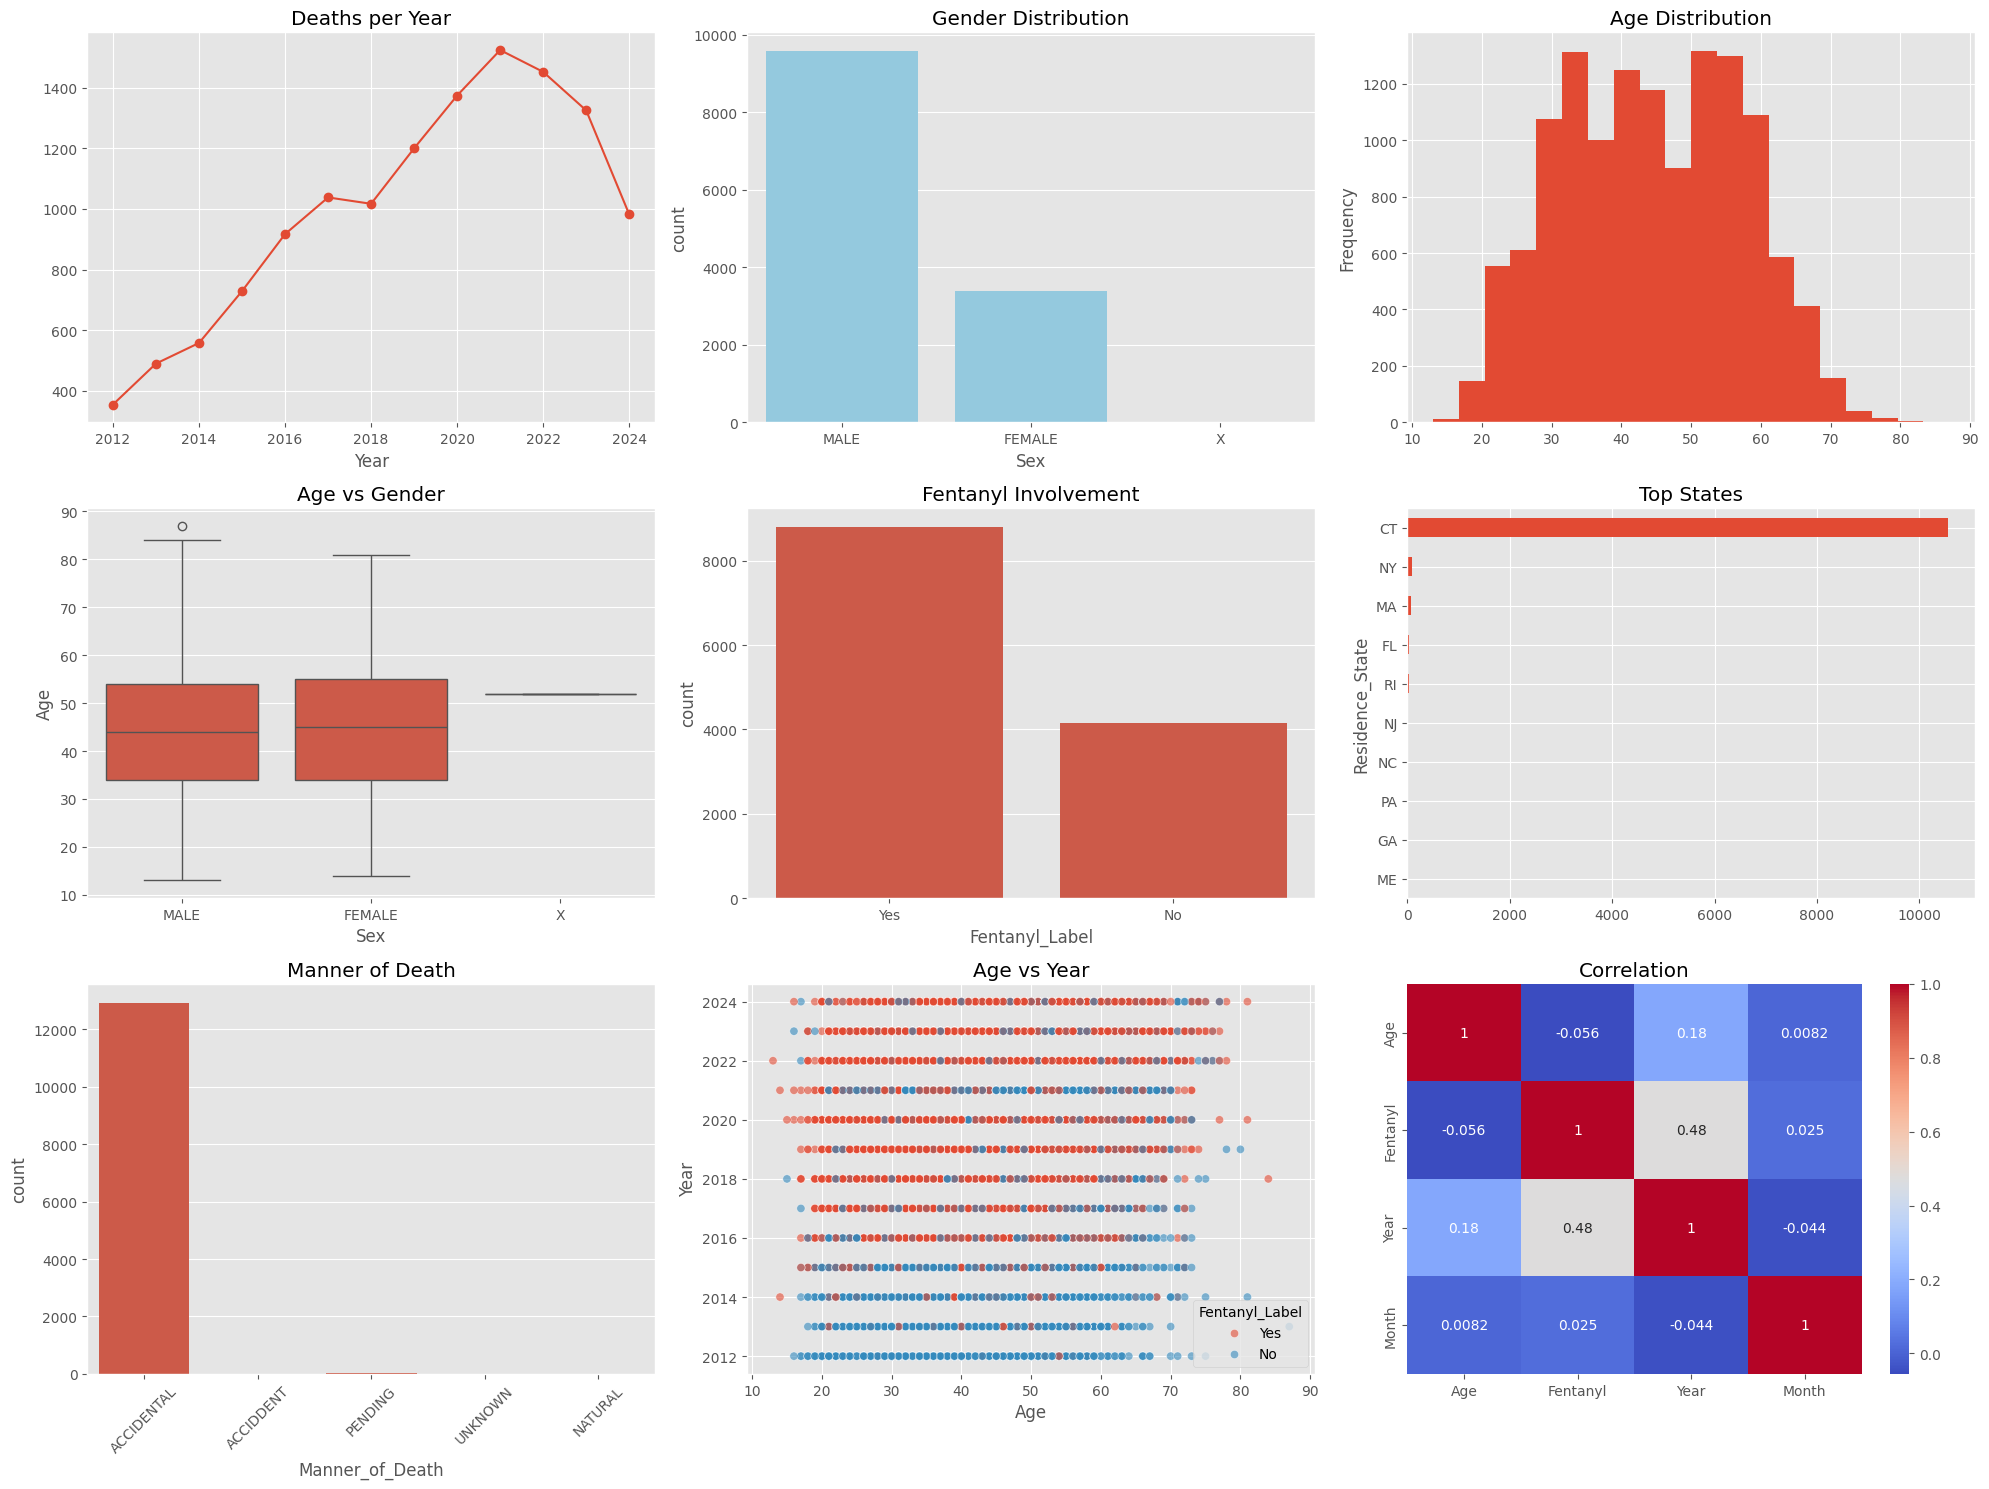

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))


plt.subplot(3, 3, 1)
df.groupby('Year').size().plot(marker='o')
plt.title("Deaths per Year")


plt.subplot(3, 3, 2)
sns.countplot(x='Sex', data=df,color="Skyblue")
plt.title("Gender Distribution")


plt.subplot(3, 3, 3)
df['Age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")

plt.subplot(3, 3, 4)
sns.boxplot(x='Sex', y='Age', data=df)
plt.title("Age vs Gender")

# 5. Countplot (Fentanyl)
plt.subplot(3, 3, 5)
sns.countplot(x='Fentanyl_Label', data=df)
plt.title("Fentanyl Involvement")

# 6. Horizontal Bar
plt.subplot(3, 3, 6)
df[df['Residence_State']!='Unknown']['Residence_State'] \
.value_counts().head(10).sort_values().plot(kind='barh')
plt.title("Top States")

# 7. Countplot (Manner of Death)
plt.subplot(3, 3, 7)
sns.countplot(x='Manner_of_Death', data=df)
plt.title("Manner of Death")
plt.xticks(rotation=45)

# 8. Scatter Plot (NEW 🔥)
plt.subplot(3, 3, 8)
sns.scatterplot(x='Age', y='Year', hue='Fentanyl_Label', data=df, alpha=0.6)
plt.title("Age vs Year")

# 9. Heatmap
plt.subplot(3, 3, 9)
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap="coolwarm")
plt.title("Correlation")

plt.tight_layout()
plt.show()

In [38]:
X = pd.get_dummies(
    df[['Age','Year','Month','Sex','Race','Manner_of_Death']], 
    drop_first=True
)

y = df['Fentanyl']


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.9, random_state=42
)

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Gradient Boosting Accuracy: 0.7834547792541792
              precision    recall  f1-score   support

           0       0.72      0.53      0.61      3735
           1       0.80      0.90      0.85      7930

    accuracy                           0.78     11665
   macro avg       0.76      0.72      0.73     11665
weighted avg       0.78      0.78      0.77     11665



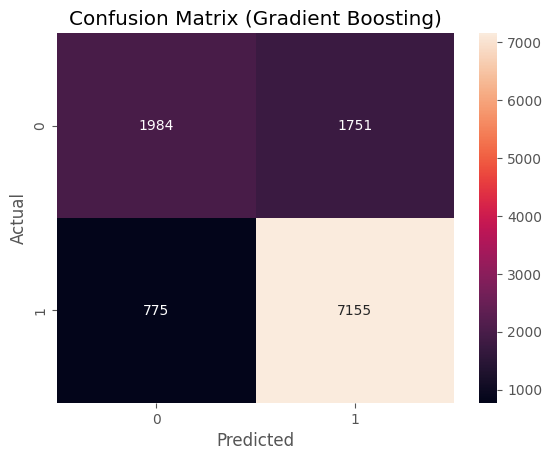

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)   # ✅ correct

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Gradient Boosting)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7834547792541792


In [46]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.65      0.55      0.59      3735
           1       0.80      0.86      0.83      7930

    accuracy                           0.76     11665
   macro avg       0.72      0.70      0.71     11665
weighted avg       0.75      0.76      0.75     11665



Text(0.5, 1.0, 'Fentanyl vs Opioid Relationship')

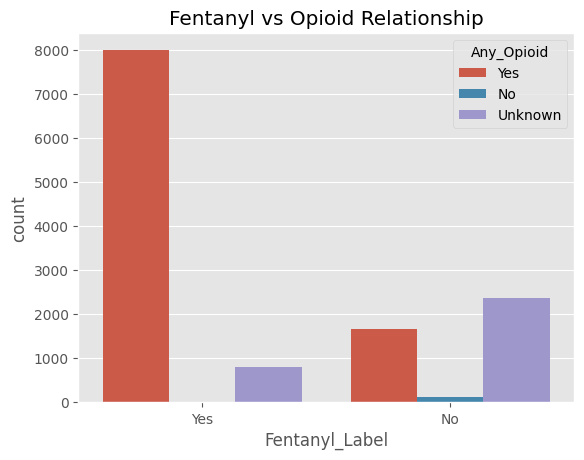

In [50]:
sns.countplot(x='Fentanyl_Label', hue='Any_Opioid', data=df)
plt.title("Fentanyl vs Opioid Relationship")

Text(0.5, 1.0, 'Fentanyl Trend Over Years')

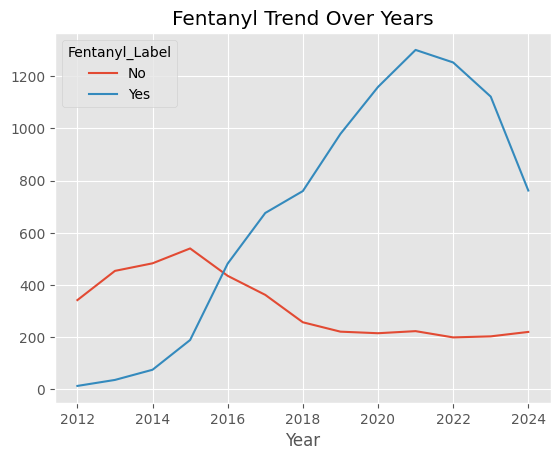

In [51]:
df.groupby(['Year','Fentanyl_Label']).size().unstack().plot()
plt.title("Fentanyl Trend Over Years")

Text(0, 0.5, 'Accuracy')

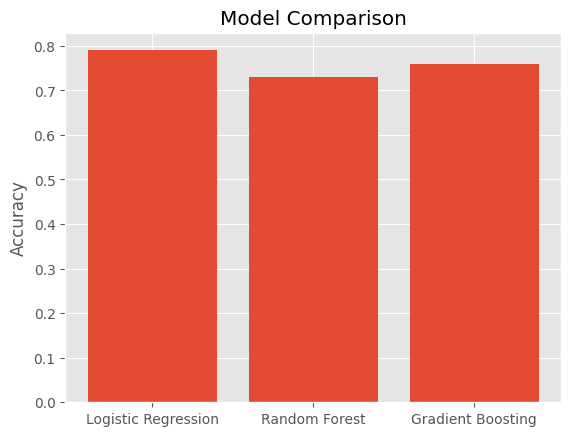

In [52]:
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
accuracy = [0.79, 0.73, 0.76]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")